<a href="https://colab.research.google.com/github/jedidiahramos/DiscreteMathClustering/blob/main/Hypervector_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kneed

In [ ]:
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem.wordnet import WordNetLemmatizer
from nltk import pos_tag

import numpy as np

from google.colab import files
import json

import re
import string

import pandas as pd

import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, OPTICS, SpectralClustering, AgglomerativeClustering, DBSCAN, MeanShift, AffinityPropagation, Birch
from sklearn.mixture import GaussianMixture
import hdbscan
import plotly.express as px
from tabulate import tabulate
from kneed import KneeLocator
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.metrics import silhouette_score
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                            v_measure_score, confusion_matrix)

In [ ]:
uploaded = files.upload()

def load_questions(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

Saving processed_LOs.json to processed_LOs (2).json
Saving processed_questions.json to processed_questions (2).json
Saving original_questions.json to original_questions (2).json


In [ ]:
def clean_text_original(text): # from https://www.kaggle.com/code/medi52/discriminative-vs-generative-text-classification
    text = text.lower()
    # Remove newline characters
    text = re.sub(r'(\S)\n(\S)',r'\1 \2',text)
    # Fix corrupted characters
    text = text.replace('â\x80\x99',"'")
    text = text.replace('\x7f',"")
    text = text.replace('â\x88\x9e',"'")
    text = text.replace('â\x89¤',"'")
    text = text.replace('â\x80\x94',"'")
    text = text.replace('â\x80\x93',"-")
    # Replace latex in-line math expressions $...$ with 'xmathx'
    text = re.sub(r'\$.+?\$','xmathx',text)
    # Replace any number that may contain a sign and a decimal part with 'xnumx'
    text = re.sub(r'-*\+*\d+\.*\d*%*','xnumx',text)
    # Matches operations between numbers expressed by a single character, such as * - + ^ /
    text = re.sub(r'\(*xnumx\)*(\s*\S{1}\s*\(*xnumx\)*)*','xnumx',text)
    # Matches physical units to some power, e.g. m^3
    text = re.sub(r'(\S)*\^(xnumx)',r'xunitx',text)
    # Matches digits and characters with no whitspace between them, such as 'NGC6752'
    text = re.sub(r'((xnumx)+[a-z]+)|([a-z]+(xnumx)+)\S*','xalphax',text)
    # Not all math formulas are enclosed in $...$. Try to catch some of these instances
    # Matches non-whitespace that has an underscore or a caret
    text = re.sub(r'\S+[_^]\S+','xmathx',text)
    # Matches non-whitespace that has a double backslash except \'
    text = re.sub(r'\S*\\[^\\\']\S+','xmathx',text)
    # Matches two non-whitespaces with a binary comparator operator in the middle
    # except '-' with optional whitespace
    text = re.sub(r'\S+\s*([=+><]|>=|=>|<=|=<|=)\s*\S+','xmathx',text)
    # Matches two math formulas with a '-' in the middle, i.e. xmathx-xmathx
    # It does not match hyphenated text
    text = re.sub(r'xmathx\s*-\s*xmathx','xmathx',text)

    return text



def clean_text_per_category(text): # Jed's code
    def insert_token(result, opening_char, token):
      while result[-1] != opening_char:
          result.pop()
      result.pop()
      for token_char in token:
          result.append(token_char)


    def tokenize_tuples(text):
        result = []
        stack = []
        for char in text:
            result.append(char)
            if char == '(':
                stack.append(char)
            elif char == ',':
                if stack and stack[-1] == '(':
                    stack[-1] = char;
            elif char == ')' and stack:
                if stack[-1] == ',':
                    insert_token(result, '(', 'tuple')
                stack.pop()
        return ''.join(result)


    def tokenize_relations(text):
        result = []
        stack = []
        for char in text:
            result.append(char)
            if char == '{':
                if stack and stack[-1] != '{' and stack[-1] != 'e':
                    stack.pop()
                stack.append(char)
            elif stack:
                if (stack[-1] == '{' and char == 't') or \
                    (stack[-1] == 't' and char == 'u') or \
                    (stack[-1] == 'u' and char == 'p') or \
                    (stack[-1] == 'p' and char == 'l') or \
                    (stack[-1] == 'l' and char == 'e'):
                    stack[-1] = char
                elif char == '}' and stack[-1] == 'e':
                    insert_token(result, '{', 'relation')
                    stack.pop()
                elif stack[-1] != '{' and stack[-1] != 'e':
                    stack.pop()
        return ''.join(result)


    def tokenize_sets(text):
        result = []
        stack = []
        for char in text:
            result.append(char)
            if char == '{':
                stack.append(char)
            elif char == '}' and stack:
                insert_token(result, '{', 'set')
                stack.pop()
        return ''.join(result)
    return tokenize_sets(tokenize_relations(tokenize_tuples(text)))

def clean_text_mix(text):
    """Pre-process text and generate tokens

    Args:
        text: Text to tokenize.

    Returns:
        Tokenized text.
    """
    text = clean_text_per_category(text) # use Jed's preprocessing
    text = re.sub(r"[A-Za-z]\s*=\s*xsetx", "xsetAssignmentx", text)
    text = re.sub(r"(?<=\b\w)-(?=\w\b)", " ", text)  # Replace dash between words

    text = re.sub(r'\$.+?\$','xmathx',text)
    # Replace any number that may contain a sign and a decimal part with 'xnumx'
    text = re.sub(r'-*\+*\d+\.*\d*%*','xnumx',text)
    # Matches operations between numbers expressed by a single character, such as * - + ^ /
    text = re.sub(r'\(*xnumx\)*(\s*\S{1}\s*\(*xnumx\)*)*','xnumx',text)
    # Matches physical units to some power, e.g. m^3
    text = re.sub(r'(\S)*\^(xnumx)',r'xunitx',text)
    # Matches digits and characters with no whitspace between them, such as 'NGC6752'
    text = re.sub(r'((xnumx)+[a-z]+)|([a-z]+(xnumx)+)\S*','xalphax',text)
    # Not all math formulas are enclosed in $...$. Try to catch some of these instances
    # Matches non-whitespace that has an underscore or a caret
    text = re.sub(r'\S+[_^]\S+','xmathx',text)
    # Matches non-whitespace that has a double backslash except \'
    text = re.sub(r'\S*\\[^\\\']\S+','xmathx',text)
    # Matches two non-whitespaces with a binary comparator operator in the middle
    # except '-' with optional whitespace
    text = re.sub(r'\S+\s*([=+><]|>=|=>|<=|=<|=)\s*\S+','xmathx',text)
    # Matches two math formulas with a '-' in the middle, i.e. xmathx-xmathx
    # It does not match hyphenated text
    text = re.sub(r'xmathx\s*-\s*xmathx','xmathx',text)


    text = str(text).lower()  # Lowercase words
    #text = re.sub(r"\[(.*?)\]", "", text)  # Remove [+XYZ chars] in content
    text = re.sub(r"\s+", " ", text)  # Remove multiple spaces in content
    text = re.sub(r"\w+…|…", "", text)  # Remove ellipsis (and last word)
    text = re.sub(
        f"[{re.escape(string.punctuation)}]", "", text
    )  # Remove punctuation


    return text

def clean_processed_questions(text):
    text = re.sub(r"[\[\]]", "", text) # remove square brackets
    text = re.sub(r"(?<=\b\w)-(?=\w\b)", " ", text)  # Replace dash between words



    text = str(text).lower()  # Lowercase words
    #text = re.sub(r"\[(.*?)\]", "", text)  # Remove [+XYZ chars] in content
    text = re.sub(r"\s+", " ", text)  # Remove multiple spaces in content
    text = re.sub(r"\w+…|…", "", text)  # Remove ellipsis (and last word)
    text = re.sub(
        f"[{re.escape(string.punctuation)}]", "", text
    )  # Remove punctuation

    return text

In [ ]:
nltk.download("punkt")
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')  # for pos_tag
nltk.download('omw-1.4')


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def tokenize_text_with_lemmatize(text):
    tokens = word_tokenize(text)  # Tokenize
    tokens = [t.lower() for t in tokens if t.isalpha()]  # Lowercase and remove non-tokenListic
    tokens = [t for t in tokens if t not in stop_words]  # Remove stopwords

    pos_tags = pos_tag(tokens)  # Get part-of-speech tags
    lemmatized = [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in pos_tags]

    return lemmatized

def tokenize_text(text):
  tokens = word_tokenize(text)  # Get tokens from text
  tokens = [t for t in tokens if not t in stop_words]  # Remove stopwords
  tokens = ["" if t.isdigit() else t for t in tokens]  # Remove digits
  tokens = [t for t in tokens if len(t) > 1]  # Remove short tokens
  return tokens

In [ ]:
clean_original_text = clean_text_mix

original_questions = load_questions('original_questions.json')
processed_questions = load_questions('processed_questions.json')
learning_outcomes = load_questions('processed_LOs.json')

data_original = []
data_processed = []

number_of_questions = len(original_questions)

for i in range(number_of_questions):
    category = list(original_questions.keys())[i]
    question_list = original_questions[category]
    for question in question_list:
        data_original.append({
            "category": category,
            "raw_question": question,
            "cleaned_question": clean_original_text(question),
            "learning_outcomes": learning_outcomes[category][i]
        })

for i in range(number_of_questions):
    category = list(processed_questions.keys())[i]
    question_list = processed_questions[category]
    for question in question_list:
        data_processed.append({
            "category": category,
            "raw_question": question,
            "cleaned_question": clean_processed_questions(question),
            "learning_outcomes": learning_outcomes[category][i]
        })


orig_df = pd.DataFrame(data_original, columns=["category", "raw_question", "cleaned_question", "learning_outcomes"])
processed_df = pd.DataFrame(data_processed, columns=["category", "raw_question", "cleaned_question", "learning_outcomes"])

orig_df_letterHV = orig_df.copy()
orig_df_wordHV = orig_df.copy()

processed_df_letterHV = processed_df.copy()
processed_df_wordHV = processed_df.copy()

In [ ]:
class Hypervector:
    def __init__(self, dimensionality):
        self.dimensionality = dimensionality
        self.vector = np.zeros(dimensionality, dtype=np.int8)

    def randomize(self):  # RANDOM VECTOR OF 1s AND -1s
        self.vector = np.random.choice([-1, 1], self.dimensionality)

    def bind(self, a, b):
        self.vector = np.multiply(a.vector, b.vector)  # PAIRWISE MULTIPLICATION

    def bundle(self, a, b):
        summed = a.vector + b.vector  # PAIRWISE ADDITION
        self.vector = np.clip(summed, -1, 1)  # KEEP THE SUM WITHIN THE RANGE [-1, 1]

    def shift_left(self, times):  # SHIFT ALL VECTOR ELEMENTS LEFT
        if times > 0: self.vector = np.roll(self.vector, -times)

    def shift_right(self, times):  # SHIFT ALL VECTOR ELEMENTS RIGHT
        if times > 0: self.vector = np.roll(self.vector, times)

    def dot_product_with(self, b):
        return np.dot(self.vector, b.vector)

    def cosine_with(self, b):
        norm_a = np.linalg.norm(self.vector)
        norm_b = np.linalg.norm(b.vector)
        return self.dot_product_with(b) / (norm_a * norm_b)

    def copy_vector(self, b):
        self.vector = np.copy(b.vector)

    def n_gram(self, n, n_vectors):
        first_vector = n_vectors[0]
        n_gram_vector = first_vector
        for i in range(1, n):
            n_vectors[i].shift_right(i)
            n_gram_vector.bind(n_gram_vector, n_vectors[i])
        return n_gram_vector

    def profile(self, seed_vectors, document, n_for_n_grams):
        element_count_minus_n_plus1 = len(document) - n_for_n_grams + 1
        for i in range(element_count_minus_n_plus1):
            # CURRENT N-GRAM
            n_vectors = [Hypervector(self.dimensionality) for x in range(n_for_n_grams)]
            element_found = True
            for j in range(n_for_n_grams):
                element = document[i + j]  # AN ELEMENT CAN BE A LETTER OR WORD
                element_found = True
                if element in seed_vectors:
                    element_vector = seed_vectors[element]
                    n_vectors[j].copy_vector(element_vector)
                else:
                    element_found = False
            if element_found: self.bundle(self, self.n_gram(n_for_n_grams, n_vectors))

class HypervectorVectorizer:
  def __init__(self, dimensionality=10000, n_for_n_grams=1):
    self.corpus = None
    self.dimensionality = dimensionality
    self.n_for_n_grams = n_for_n_grams
    self.tokenList_vectors = {}

  def add_token_if_not_yet_added(self, token):
    if token not in self.tokenList_vectors:
      self.tokenList_vectors[token] = Hypervector(self.dimensionality)

  def fill_tokenList(self):
    for document in self.corpus:
      for token in document:
        self.add_token_if_not_yet_added(token)

  def randomize_tokenList_vectors(self):
    for tokenList_vector in self.tokenList_vectors:
      self.tokenList_vectors[tokenList_vector].randomize()

  def vectorize_documents_in_corpus(self, corpus):
    self.corpus = corpus
    self.fill_tokenList()
    self.randomize_tokenList_vectors()
    vectors = []

    print("ALPHABET VECTORS:")
    for token_vector in self.tokenList_vectors:
      print(token_vector + ":", self.tokenList_vectors[token_vector].vector)
    print()

    for document in self.corpus:
      document_vector = Hypervector(self.dimensionality)
      document_vector.profile(self.tokenList_vectors, document, self.n_for_n_grams)
      vectors.append(document_vector.vector)

    return vectors


def hypervector_vectorize(list_of_docs, vectorizer):
  X = vectorizer.vectorize_documents_in_corpus(list_of_docs)
  return X

In [ ]:
def reduce_dims_pca(df, vectors, n_components=2):
  X = np.vstack(vectors)
  pca = PCA(n_components=n_components)
  X_reduced = pca.fit_transform(X)
  if n_components == 2:
    df[['x', 'y']] = X_reduced
  return X_reduced

def reduce_dims_tsne(df, vectors, n_components=2):
  X = np.vstack(vectors)
  tsne = TSNE(n_components=n_components)
  X_reduced = tsne.fit_transform(X)
  if n_components == 2:
    df[['x', 'y']] = X_reduced
  return X_reduced

def reduce_dims_umap(df, vectors, n_components=2, n_neighbors=15, min_dist=0.1):
    X = np.vstack(vectors)
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist)
    X_reduced = reducer.fit_transform(X)
    if n_components == 2:
      df[['x', 'y']] = X_reduced
    return X_reduced

def reduce_to_2d_pca_tsne(df, vectors):
  X = np.vstack(vectors)
  pca = PCA(n_components=10)
  X_reduced = pca.fit_transform(X)

  tsne = TSNE(n_components=2, random_state=0)
  X_2d = tsne.fit_transform(X_reduced)

  df[['x', 'y']] = X_2d

def visualize_plot(title, df, cluster_column):
    # Scatter plot using Plotly Express
    fig = px.scatter(df, x="x", y="y", color=cluster_column,
                     color_continuous_scale='viridis',
                     title=title,
                     labels={"x": "t-SNE Component 1", "y": "t-SNE Component 2", cluster_column: "Cluster"},
                     hover_data=["category", "learning_outcomes"])

    fig.update_traces(marker=dict(size=10))  # Adjust marker size
    fig.show()

    # Loop through each cluster and plot category distribution as a pie chart
    groups = df.groupby(cluster_column)

    for cluster, group in groups:
      # Count occurrences of each category within the cluster
      category_counts = group['category'].value_counts().reset_index()
      category_counts.columns = ['Category', 'Count']

      # Calculate percentages for each category
      total_count = category_counts['Count'].sum()
      category_counts['Percentage'] = (category_counts['Count'] / total_count) * 100

      # Round values for prettier display
      category_counts['Percentage'] = category_counts['Percentage'].round(2)

      # Print the category distribution for the current cluster in a clean table
      print(f"\nCluster {cluster} Category Distribution:")
      print(tabulate(category_counts, headers='keys', tablefmt='fancy_grid', showindex=False))

def cluster_all_euclidean(vectors, num_clusters, df, random_state=0):
    """
    Perform clustering on document vectors, reduce dimensions, and plot clusters.

    Args:
        vectors: List of document vectors (e.g., output from vectorize function)
        num_clusters: Number of clusters for KMeans
        df: DataFrame containing the documents

    Returns:
        DataFrame with added 'cluster', 'x', and 'y' columns for visualization
    """

    # Step 1: Convert vectors to numpy array and perform KMeans clustering
    X = np.vstack(vectors)

    kmeans = KMeans(n_clusters=num_clusters, random_state=random_state)
    df["cluster_kmeans"] = kmeans.fit_predict(X)

    dbscan = DBSCAN(eps=0.1, min_samples=2)
    df["cluster_dbscan"] = dbscan.fit_predict(X)

    clustering_optics = OPTICS(min_samples=10, xi=.01, min_cluster_size=.05).fit_predict(X)
    df["cluster_optics"] = clustering_optics

    clustering_hdbscan = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True).fit_predict(X)
    df["cluster_hdbscan"] = clustering_hdbscan

    clustering_spectral = SpectralClustering(n_clusters=num_clusters, assign_labels='discretize', random_state=random_state).fit_predict(X)
    df["cluster_spectral"] = clustering_spectral

    clustering_gmm = GaussianMixture(n_components=num_clusters, random_state=random_state).fit_predict(X)
    df["cluster_gmm"] = clustering_gmm

    clustering_agglo = AgglomerativeClustering(n_clusters=num_clusters).fit_predict(X)
    df["cluster_agglo"] = clustering_agglo

    clustering_meanshift = MeanShift().fit_predict(X)
    df["cluster_meanshift"] = clustering_meanshift

    clustering_affinity = AffinityPropagation(random_state=random_state).fit_predict(X)
    df["cluster_affinity"] = clustering_affinity

    clustering_birch = Birch(n_clusters=num_clusters).fit_predict(X)
    df["cluster_birch"] = clustering_birch

def cluster_all_cosine(vectors, num_clusters, df, random_state=0):
    """
    Perform clustering using cosine similarity across multiple clustering algorithms.

    Args:
        vectors: List of document vectors (will be normalized inside)
        num_clusters: Number of clusters for algorithms that require it
        df: DataFrame to store clustering results
        eps: DBSCAN epsilon value
        min_samples: DBSCAN/OPTICS/HDBSCAN minimum samples

    Returns:
        DataFrame with cluster labels added
    """
    # Normalize input vectors for cosine similarity
    X = normalize(np.vstack(vectors), norm='l2')

    # Cosine similarity and distance matrices
    cosine_sim = cosine_similarity(X)
    cosine_dist = 1 - cosine_sim

    # Ensure cosine_dist is in double precision (double_t)
    cosine_dist = cosine_dist.astype(np.float64)  # Convert to double_t

    # KMeans (approximate cosine)
    df["cluster_kmeans"] = KMeans(n_clusters=num_clusters, random_state=random_state).fit_predict(X)

    # DBSCAN with cosine metric
    df["cluster_dbscan"] = DBSCAN(metric='cosine', eps=0.1, min_samples=2).fit_predict(X)

    # OPTICS with cosine metric
    df["cluster_optics"] = OPTICS(metric='cosine', min_samples=10, xi=0.01, min_cluster_size=0.05).fit_predict(X)

    # HDBSCAN with precomputed cosine distance
    df["cluster_hdbscan"] = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True, metric='precomputed').fit_predict(cosine_dist)

    # Spectral clustering with precomputed cosine similarity
    df["cluster_spectral"] = SpectralClustering(
        n_clusters=num_clusters,
        affinity='precomputed',
        assign_labels='discretize',
        random_state=random_state
    ).fit_predict(cosine_sim)

    # Gaussian Mixture (approximate cosine)
    df["cluster_gmm"] = GaussianMixture(n_components=num_clusters, random_state=random_state).fit_predict(X)

    # Agglomerative Clustering with cosine distance
    df["cluster_agglo"] = AgglomerativeClustering(
        n_clusters=num_clusters,
        metric='precomputed',
        linkage='average'
    ).fit(cosine_dist).labels_

    # MeanShift (approximate cosine)
    df["cluster_meanshift"] = MeanShift().fit_predict(X)

    # Affinity Propagation with precomputed cosine similarity
    df["cluster_affinity"] = AffinityPropagation(affinity='precomputed', random_state=random_state).fit_predict(cosine_sim)

    # Birch (approximate cosine)
    df["cluster_birch"] = Birch(n_clusters=num_clusters).fit_predict(X)

    return df


def visualize_all_clusters(df):
    visualize_plot("KMeans Clusters of Questions", df, "cluster_kmeans")
    visualize_plot("DBSCAN Clusters of Questions", df, "cluster_dbscan")
    visualize_plot("OPTICS Clusters of Questions", df, "cluster_optics")
    visualize_plot("HDBSCAN Clusters of Questions", df, "cluster_hdbscan")
    visualize_plot("Spectral Clusters of Questions", df, "cluster_spectral")
    visualize_plot("GMM Clusters of Questions", df, "cluster_gmm")
    visualize_plot("Agglomerative Clusters of Questions", df, "cluster_agglo")
    visualize_plot("MeanShift Clusters of Questions", df, "cluster_meanshift")
    visualize_plot("AffinityPropagation Clusters of Questions", df, "cluster_affinity")
    visualize_plot("Birch Clusters of Questions", df, "cluster_birch")

In [ ]:
def listInfo(vectors, withL2Normalization=False):
  if withL2Normalization:
    vectors = normalize(vectors, norm='l2')
  pca = PCA()
  X_pca = pca.fit_transform(vectors)

  explained_variance = pca.explained_variance_ratio_
  cumulative_variance = np.cumsum(explained_variance)

  # Plot to visualize how many components to keep
  plt.figure(figsize=(8, 5))
  plt.plot(cumulative_variance, marker='o')
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.grid(True)
  plt.title('Explained Variance vs Number of Components')
  plt.show()

  desired_variance = 0.99  # 95% of total variance
  n_components = np.argmax(cumulative_variance >= desired_variance) + 1
  print(f"Number of components to reach {desired_variance*100}% variance: {n_components}")

  inertias = []
  K = range(1, 21)  # Try k from 1 to 10

  for k in K:
      kmeans = KMeans(n_clusters=k, random_state=42)
      kmeans.fit(vectors)  # X is your feature matrix
      inertias.append(kmeans.inertia_)

  plt.plot(K, inertias, marker='o')
  plt.xlabel('Number of clusters (k)')
  plt.ylabel('Inertia')
  plt.title('Elbow Method for Optimal k')
  plt.grid(True)
  plt.show()

  kl = KneeLocator(K, inertias, curve="convex", direction="decreasing")
  optimal_k = kl.elbow
  print(f"Optimal number of clusters: {optimal_k}")

In [ ]:
def generate_dendrogram_data_euclidean(vectors):
    """Computes the linkage matrix for hierarchical clustering."""
    Z = linkage(vectors, method='ward')
    return Z

def generate_dendrogram_data_cosine(vectors):
    """Computes the linkage matrix using cosine distance for hierarchical clustering."""
    cosine_dist = pdist(vectors, metric='cosine')  # Convert similarity to distance
    Z = linkage(cosine_dist, method='average')  # Use 'average' or 'complete', not 'ward' with cosine
    return Z

def plot_dendrogram(Z, ques, cutoff=None):
    """Plots the dendrogram from the linkage matrix."""
    fig, ax = plt.subplots(figsize=(18, 30))

    # Generate dendrogram labels mapping
    R = dendrogram(Z, orientation="left", labels=ques.tolist(), no_plot=True)
    temp = {R["leaves"][ii]: ques[ii] for ii in range(len(R["leaves"]))}

    # Label function for dendrogram leaves
    def llf(xx):
        return "{}".format(temp[xx])

    # Plot the actual dendrogram
    dendrogram(
        Z,
        orientation="left",
        leaf_label_func=llf,
        leaf_font_size=10.,
    )

    # Draw cutoff line only if a value is provided
    if cutoff is not None:
        plt.axvline(x=cutoff, color='r', linestyle='--')

    plt.show()

def create_clusters_from_cutoff(df, cutoff, Z):
  test = cut_tree(Z, height=cutoff)
  df['h_cluster'] = test.flatten()

def create_n_clusters_from_dendogram(df, n_clusters, Z):
  test = cut_tree(Z, n_clusters=n_clusters)
  df['h_cluster'] = test.flatten()

In [ ]:
def score(vectors, df, metric="cosine"):
    """
    Calculate the Silhouette Score for each clustering algorithm and print it.

    Args:
        vectors: List or array of document vectors
        df: DataFrame containing cluster labels
        metric: 'cosine' or 'euclidean'
    """
    X = np.vstack(vectors)
    X_norm = normalize(X, axis=1) if metric == "cosine" else X

    def compute_score(X_subset, labels, metric):
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            return np.nan
        return silhouette_score(X_subset, labels, metric=metric)

    def safe_labels(col_name):
        labels = df[col_name].values
        mask = labels != -1
        indices_to_keep = np.where(mask)[0]
        assert len(X_norm[indices_to_keep]) == len(labels[indices_to_keep]), "Lengths do not match"
        return X_norm[indices_to_keep], labels[indices_to_keep]

    scores = {}

    scores["kmeans"] = compute_score(X_norm, df["cluster_kmeans"].values, metric)

    X_dbscan, labels_dbscan = safe_labels("cluster_dbscan")
    scores["dbscan"] = compute_score(X_dbscan, labels_dbscan, metric)

    X_optics, labels_optics = safe_labels("cluster_optics")
    scores["optics"] = compute_score(X_optics, labels_optics, metric)

    X_hdbscan, labels_hdbscan = safe_labels("cluster_hdbscan")
    scores["hdbscan"] = compute_score(X_hdbscan, labels_hdbscan, metric)

    scores["spectral"] = compute_score(X_norm, df["cluster_spectral"].values, metric)
    scores["gmm"] = compute_score(X_norm, df["cluster_gmm"].values, metric)

    agglo_labels = df["cluster_agglo"].values
    if metric == "cosine":
        cosine_dist = 1 - np.dot(X_norm, X_norm.T)
        cosine_dist = np.clip(cosine_dist, 0, None)
        scores["agglo"] = compute_score(cosine_dist, agglo_labels, metric="precomputed")
    else:
        scores["agglo"] = compute_score(X_norm, agglo_labels, metric)

    scores["meanshift"] = compute_score(X_norm, df["cluster_meanshift"].values, metric)
    scores["affinity"] = compute_score(X_norm, df["cluster_affinity"].values, metric)
    scores["birch"] = compute_score(X_norm, df["cluster_birch"].values, metric)

    for algo, val in scores.items():
        print(f"{algo.capitalize()} Silhouette Score ({metric}): {val}")
    res = pd.DataFrame(list(scores.items()), columns=['cluster', 'silhouette_score'])
    return res

def average_cluster_purities(df, cluster):
  if -1 in df[cluster].unique():
    additional_message = "excluding noise"
  else:
    additional_message = ""
  DF = df[df[cluster] != -1]
  max_percentages = (
    DF.groupby(cluster)['category']
    .value_counts(normalize=True)
    .groupby(cluster)
    .max()
  )
  average_max_percentage = max_percentages.mean()
  num_clusters = DF[cluster].nunique()

  print(f"Averaged purity of {cluster} for {num_clusters} clusters {additional_message}:", average_max_percentage)
  return num_clusters, average_max_percentage

def get_all_average_cluster_purities(df):
  res = pd.DataFrame(columns=['cluster', 'num_clusters', 'average_purity'])
  for cluster in ['cluster_kmeans', 'cluster_dbscan', 'cluster_optics', 'cluster_hdbscan', 'cluster_spectral', 'cluster_gmm', 'cluster_agglo', 'cluster_meanshift', 'cluster_affinity', 'cluster_birch']:
    num_clusters, average_purity = average_cluster_purities(df, cluster)
    res.loc[len(res)] = [cluster, num_clusters, average_purity]
  return res

def weighted_average_cluster_purities(df, cluster):
  if -1 in df[cluster].unique():
    additional_message = "excluding noise"
  else:
    additional_message = ""
  DF = df[df[cluster] != -1]
  max_percentages = (
    DF.groupby(cluster)['category']
    .value_counts(normalize=True)
    .groupby(cluster)
    .max()
  )
  average_max_percentage = max_percentages.mean()

  cluster_sizes = DF[cluster].value_counts()
  total_points = len(df)
  num_clusters = DF[cluster].nunique()

  weighted_avg = (max_percentages * (cluster_sizes / total_points)).sum()

  print(f"Weighted average purity of {cluster} for {num_clusters} clusters {additional_message}:", weighted_avg)
  return num_clusters, weighted_avg

def get_all_weighted_average_cluster_purities(df):
  res = pd.DataFrame(columns=['cluster', 'num_clusters', 'weighted_average_purity'])
  for cluster in ['cluster_kmeans', 'cluster_dbscan', 'cluster_optics', 'cluster_hdbscan', 'cluster_spectral', 'cluster_gmm', 'cluster_agglo', 'cluster_meanshift', 'cluster_affinity', 'cluster_birch']:
    num_clusters, weighted_avg = weighted_average_cluster_purities(df, cluster)
    res.loc[len(res)] = [cluster, num_clusters, weighted_avg]
  return res

def evaluate_clustering(df, cluster_col='cluster', category_col='category'):
    """
    Evaluate clustering performance given a DataFrame with true categories and cluster assignments.

    Parameters:
    - df: DataFrame containing the data
    - category_col: Name of column with ground truth categories (default 'category')
    - cluster_col: Name of column with cluster assignments (default 'cluster')

    Prints:
    - Adjusted Rand Index (ARI)
    - Normalized Mutual Information (NMI)
    - V-Measure (harmonic mean of homogeneity/completeness)
    - Weighted Purity (size-adjusted cluster purity)
    """
    true = df[category_col]
    pred = df[cluster_col]

    # Calculate metrics
    ari = adjusted_rand_score(true, pred)
    nmi = normalized_mutual_info_score(true, pred)
    v_score = v_measure_score(true, pred)


    # Print results
    print(f"Clustering Evaluation Metrics:")
    print(f"- Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"- Normalized Mutual Info (NMI): {nmi:.4f}")
    print(f"- V-Measure: {v_score:.4f}")

    return ari, nmi, v_score


def evaluate_all_clusterings(df, category_col='category'):
    """
    Evaluate ALL clustering algorithm results in a DataFrame against ground truth.
    Automatically detects all columns starting with 'cluster_' for evaluation.

    Parameters:
    - df: DataFrame containing the data
    - category_col: Name of column with ground truth categories
    """
    res = pd.DataFrame(columns=['cluster', 'ari', 'nmi', 'v_score'])
    # Find all clustering result columns
    cluster_cols = [col for col in df.columns
                   if col.startswith('cluster_') and col != category_col]

    if not cluster_cols:
        raise ValueError("No clustering columns found (expected columns starting with 'cluster_')")

    print(f"Evaluating {len(cluster_cols)} clustering algorithms against '{category_col}':\n")

    # Evaluate each clustering method
    for cluster_col in cluster_cols:
        print(f"\n╔{'═'*50}╗")
        print(f"║ {cluster_col.upper().replace('_', ' '):^48} ║")
        print(f"╚{'═'*50}╝")

        ari, nmi, v_score = evaluate_clustering(df, category_col=category_col, cluster_col=cluster_col)
        res.loc[len(res)] = [cluster_col, ari, nmi, v_score]

        print("\n" + "─"*60)
    return res

In [ ]:
def list_cluster_LOs(df, cluster_type):
  groups = df.groupby(cluster_type)
  for group, group_df in groups:
    print(f"\nCluster {group}")
    for LOs in group_df["learning_outcomes"]:
      for LO in LOs:
        print(LO)

In [ ]:
vectorizer = HypervectorVectorizer(dimensionality=10000, n_for_n_grams=1)

ALPHABET VECTORS:
L: [ 1 -1 -1 ... -1  1  1]
e: [-1 -1  1 ...  1 -1  1]
t: [ 1 -1  1 ...  1 -1  1]
 : [ 1 -1  1 ...  1  1  1]
[: [-1  1 -1 ...  1  1 -1]
u: [ 1  1  1 ... -1  1  1]
n: [-1  1  1 ... -1  1  1]
i: [-1  1  1 ... -1  1 -1]
v: [ 1  1  1 ...  1 -1 -1]
r: [ 1  1  1 ...  1 -1 -1]
s: [-1 -1 -1 ... -1 -1  1]
a: [ 1 -1 -1 ... -1 -1 -1]
l: [-1  1 -1 ...  1  1 -1]
]: [ 1 -1  1 ... -1  1  1]
b: [ 1 -1  1 ...  1 -1 -1]
h: [-1  1 -1 ... -1 -1  1]
o: [-1 -1 -1 ... -1  1  1]
f: [ 1 -1 -1 ...  1 -1 -1]
d: [-1 -1  1 ...  1 -1  1]
y: [ 1 -1 -1 ...  1 -1 -1]
.: [ 1 -1 -1 ...  1  1  1]
w: [ 1 -1 -1 ...  1  1 -1]
-: [ 1  1 -1 ... -1  1 -1]
,: [ 1 -1 -1 ... -1  1  1]
c: [-1 -1 -1 ... -1 -1 -1]
m: [ 1 -1  1 ...  1 -1 -1]
j: [-1  1  1 ...  1 -1  1]
M: [ 1 -1  1 ...  1 -1 -1]
g: [-1  1 -1 ...  1 -1  1]
2: [ 1  1 -1 ... -1 -1 -1]
A: [ 1  1 -1 ... -1 -1 -1]
T: [ 1 -1  1 ... -1 -1  1]
E: [-1  1  1 ...  1  1  1]
x: [ 1  1 -1 ...  1  1 -1]
p: [ 1 -1 -1 ... -1 -1  1]
:: [-1  1 -1 ...  1 -1  1]

: [-1  1 

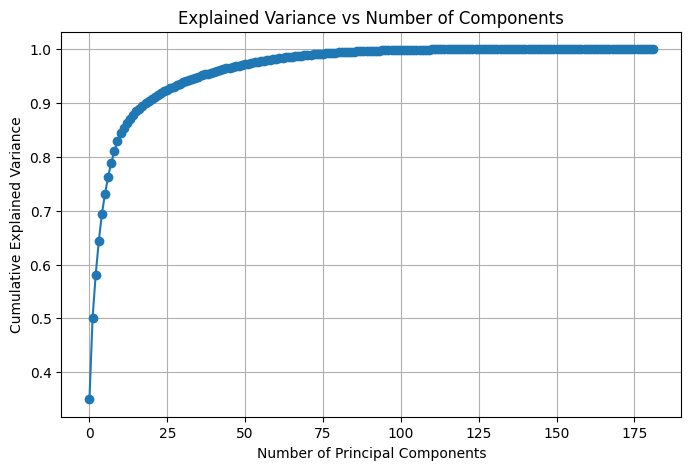

Number of components to reach 99.0% variance: 72


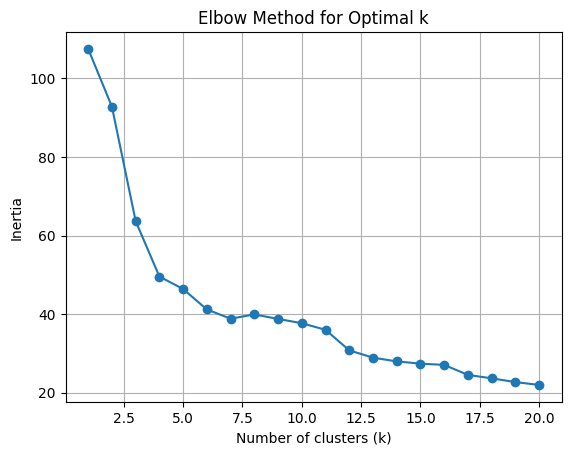

Optimal number of clusters: 6


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.




Cluster Formal Logic Category Distribution:
╒══════════════╤═════════╤══════════════╕
│ Category     │   Count │   Percentage │
╞══════════════╪═════════╪══════════════╡
│ Formal Logic │      48 │          100 │
╘══════════════╧═════════╧══════════════╛

Cluster Functions Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Functions  │      61 │          100 │
╘════════════╧═════════╧══════════════╛

Cluster Relations Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Relations  │      43 │          100 │
╘════════════╧═════════╧══════════════╛

Cluster Sets, Proofs, and Induction Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction 

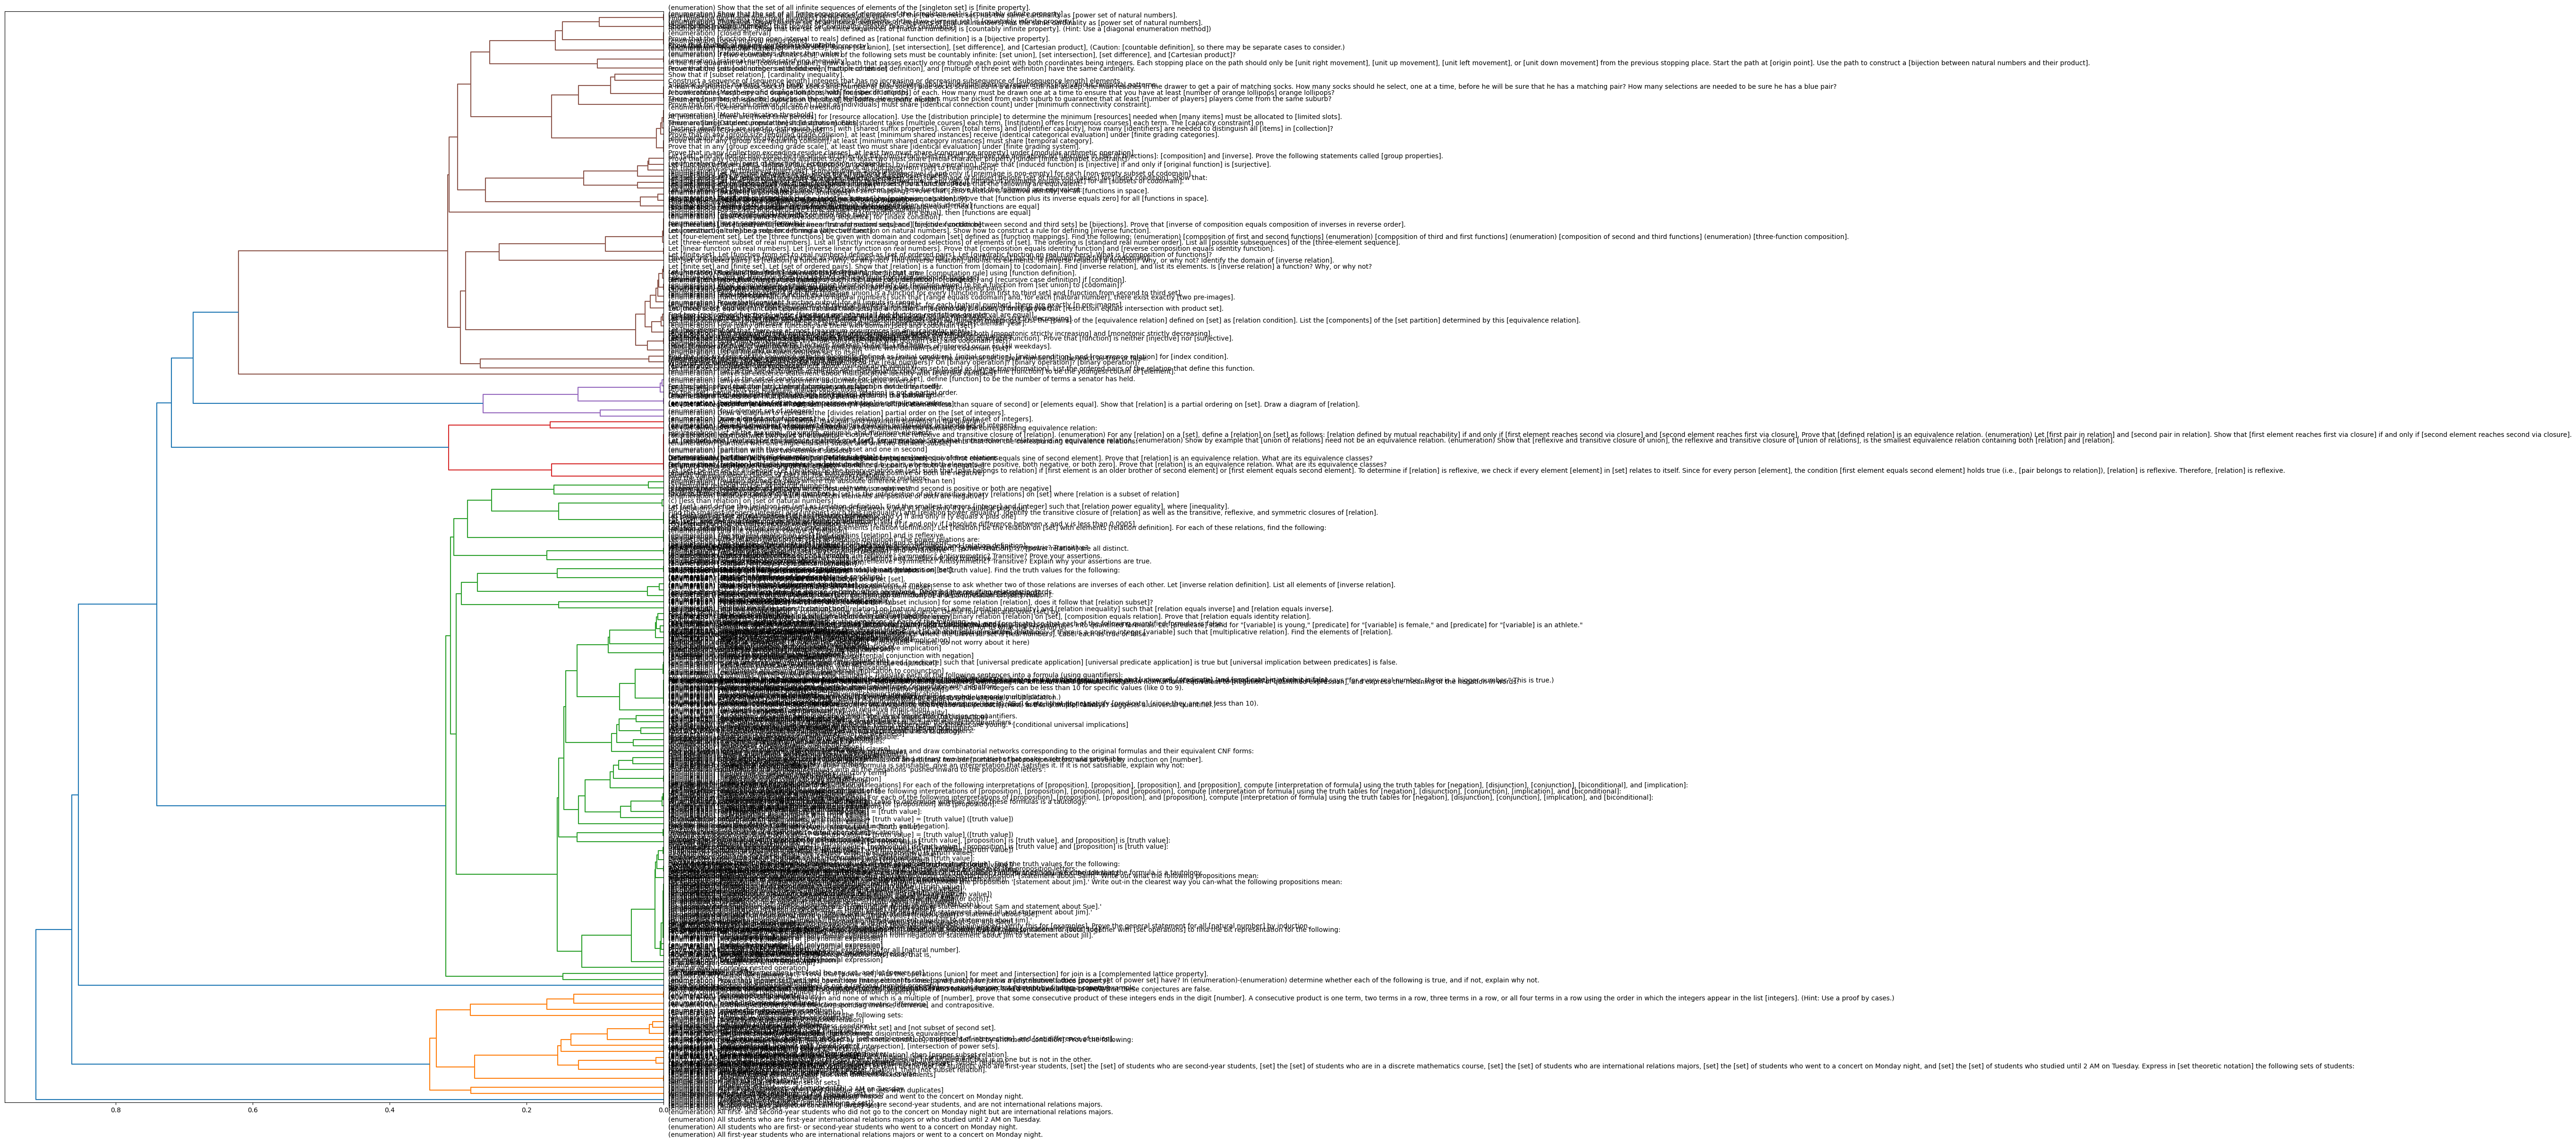

In [ ]:
metric = 'cosine'
is_euclidean = metric == 'euclidean'

df = processed_df_letterHV
corpus = df["raw_question"]
vectors = hypervector_vectorize(corpus, vectorizer)
listInfo(vectors, withL2Normalization=not is_euclidean)

reduce_dims_umap(df, vectors, 2)
visualize_plot("Original categories", df, "category")

dendogram = generate_dendrogram_data_euclidean(vectors) if is_euclidean else generate_dendrogram_data_cosine(vectors)
plot_dendrogram(dendogram, df["raw_question"])

In [ ]:
vectors = reduce_dims_umap(df, vectors, 150)

k = 9
if is_euclidean:
  cluster_all_euclidean(vectors, k, df)
else:
  cluster_all_cosine(vectors, k, df)

create_n_clusters_from_dendogram(df, k, dendogram)
visualize_all_clusters(df)
visualize_plot("hierarchical clustering", df, "h_cluster")

scores = score(vectors, df, metric=metric)
print()
avgs = get_all_average_cluster_purities(df)
print()
w_avgs = get_all_weighted_average_cluster_purities(df)
print()
eval = evaluate_all_clusterings(df)

avgs.drop(columns=['cluster'])
w_avgs.drop(columns=['cluster'])
eval.drop(columns=['cluster'])

final = pd.concat([scores, avgs[['num_clusters', 'average_purity']], w_avgs[['weighted_average_purity']], eval[['ari', 'nmi', 'v_score']]], axis=1)
print(final['weighted_average_purity'].mean())

final.to_csv("results.csv", index=False)
#files.download("results.csv")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning:

Affinity propagation did not converge, this model may return degenerate cluster centers and labels.

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_birch.py:727: ConvergenceWarning:

Number of subclusters found (1) by BIRCH is less than (9). Decrease the threshold.




Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       4 │        36.36 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │       4 │        36.36 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       2 │        18.18 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       1 │         9.09 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       9 │        33.33 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic      


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      61 │        33.52 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │      48 │        26.37 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      43 │        23.63 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      30 │        16.48 │
╘═════════════════════════════╧═════════╧══════════════╛



Cluster -1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      10 │        47.62 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       6 │        28.57 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       3 │        14.29 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │       2 │         9.52 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │       5 │        45.45 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and


Cluster -1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │       8 │           80 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │       1 │           10 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │       1 │           10 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │       9 │        50    │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       7 │        38.89 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and

...


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      24 │        51.06 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      11 │        23.4  │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       6 │        12.77 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │       6 │        12.77 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       9 │        33.33 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic      


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      28 │        48.28 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      12 │        20.69 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      10 │        17.24 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       8 │        13.79 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │      15 │        27.78 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and 


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       1 │          100 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       1 │          100 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 2 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │      12 │        33.33 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      10 │  


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      61 │        33.52 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │      48 │        26.37 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      43 │        23.63 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      30 │        16.48 │
╘═════════════════════════════╧═════════╧══════════════╛



Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      39 │        46.43 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      22 │        26.19 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      12 │        14.29 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │      11 │        13.1  │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │      22 │        36.67 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and 

In [ ]:
def export_to_file(df, filename):
  df.to_csv(f"{filename}.csv", index=False)

  files.download(f"{filename}.csv")

In [ ]:
export_to_file(df, "processed_hypervectors(cosine)df")
export_to_file(final, "processed_hypervectors(cosine)results")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>